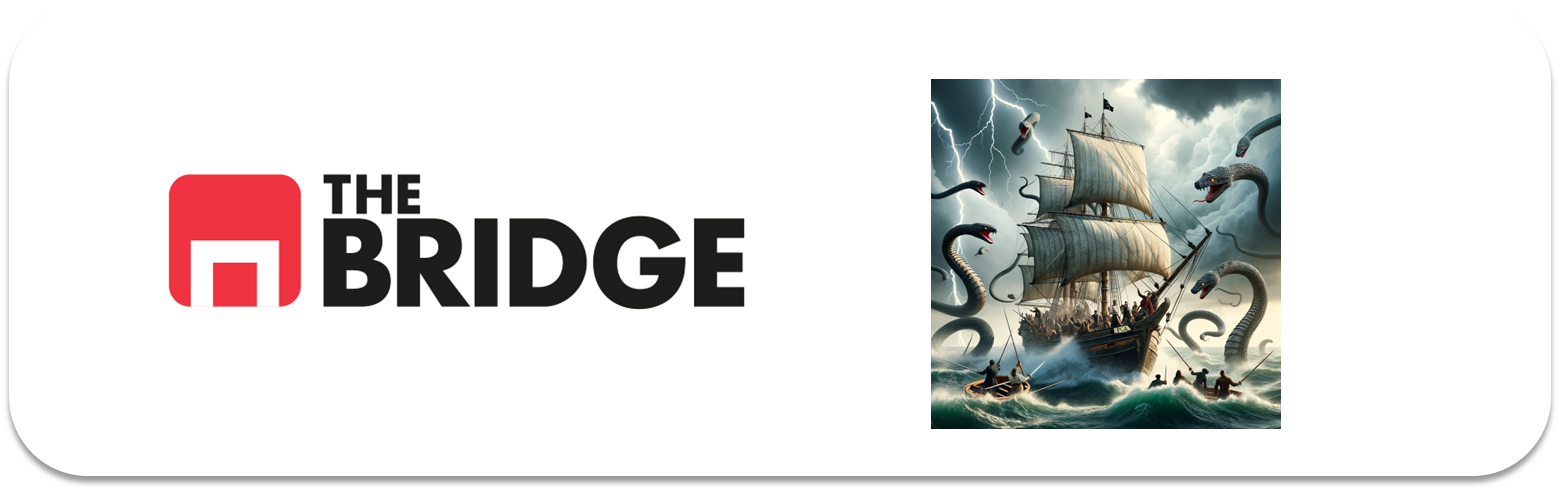

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score


### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




Shape dataset: (400, 4097)
Clases (personas): 40
Imagenes por persona: 10
Features (pixels): 4096

X_train: (320, 4096)  |  X_test: (80, 4096)
Test tiene 80 muestras (>= 80 OK)

Rango valores: [0.000, 1.000]
Media: 0.547  |  Std: 0.173
Pixels normalizados en [0,1] -> no se requiere escalado adicional.


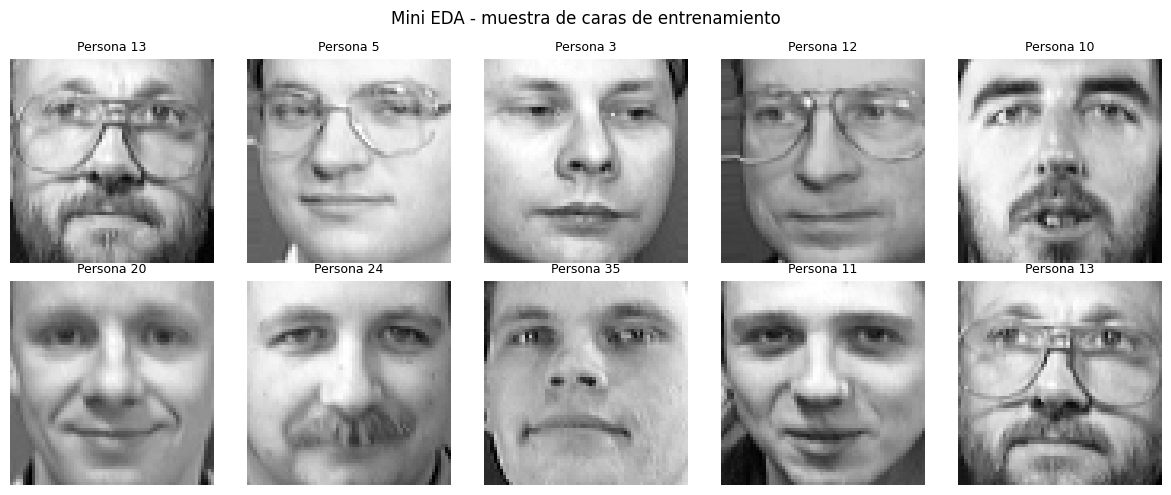


Baseline CV  (5-fold, balanced_accuracy): 0.9350  (93.50%)


Baseline Test (balanced_accuracy):        0.9500  (95.00%)

Features originales: 4096 (pixels por imagen)


In [2]:
# == Cargar dataset ===============================================
olivetti = fetch_olivetti_faces(random_state=42)
X = olivetti.data      # (400, 4096)
y = olivetti.target    # (400,) -> clases 0-39

# Construir DataFrame
df = pd.DataFrame(X)
df['target'] = y
n_clases = len(np.unique(y))
print(f"Shape dataset: {df.shape}")
print(f"Clases (personas): {n_clases}")
print(f"Imagenes por persona: {len(y) // n_clases}")
print(f"Features (pixels): {X.shape[1]}")

# == Split estratificado (>= 80 muestras en test) =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Test tiene {X_test.shape[0]} muestras (>= 80 OK)")

# == Mini EDA =====================================================
# Las imagenes de Olivetti ya vienen normalizadas en [0, 1].
# No hay valores nulos (dataset limpio de sklearn).
# No se aplica escalado adicional: pixeles ya en escala uniforme.
print(f"\nRango valores: [{X.min():.3f}, {X.max():.3f}]")
print(f"Media: {X.mean():.3f}  |  Std: {X.std():.3f}")
print("Pixels normalizados en [0,1] -> no se requiere escalado adicional.")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Persona {y_train[i]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Mini EDA - muestra de caras de entrenamiento", fontsize=12)
plt.tight_layout()
plt.show()

# == Modelo baseline (todas las features, sin PCA) ================
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

scores_cv_base = cross_val_score(
    rf_base, X_train, y_train, cv=5, scoring='balanced_accuracy'
)
baseline_cv = scores_cv_base.mean()
print(f"\nBaseline CV  (5-fold, balanced_accuracy): {baseline_cv:.4f}  ({baseline_cv*100:.2f}%)")

rf_base.fit(X_train, y_train)
baseline_test = balanced_accuracy_score(y_test, rf_base.predict(X_test))
print(f"Baseline Test (balanced_accuracy):        {baseline_test:.4f}  ({baseline_test*100:.2f}%)")
print(f"\nFeatures originales: {X_train.shape[1]} (pixels por imagen)")


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

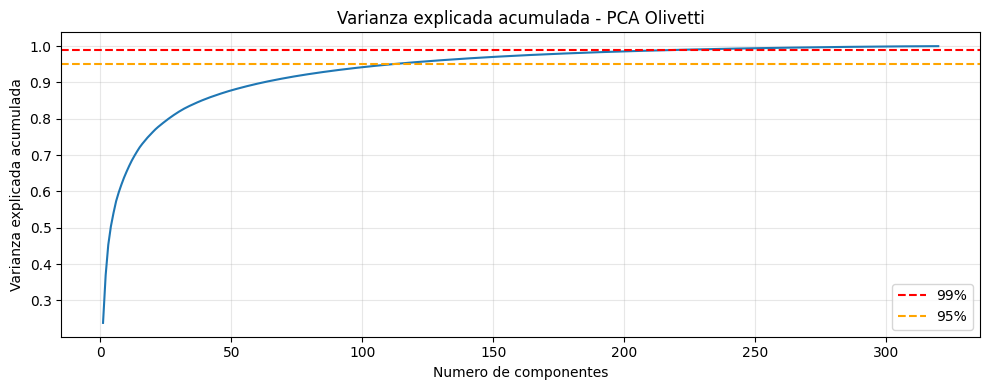

Rango compresion Parte 2:
  n= 10 -> 0.244%
  n= 25 -> 0.610%
  n= 50 -> 1.221%
  n= 75 -> 1.831%
  n=100 -> 2.441%


PCs= 10 (0.244%) | CV=0.8525 | Test=0.7750


PCs= 25 (0.610%) | CV=0.9150 | Test=0.8875


PCs= 50 (1.221%) | CV=0.9025 | Test=0.9375


PCs= 75 (1.831%) | CV=0.9200 | Test=0.9250


PCs=100 (2.441%) | CV=0.9025 | Test=0.9375

Resumen Parte 2:
 n_componentes  compresion_%  balanced_acc_CV  balanced_acc_test  diff_CV_vs_baseline  diff_test_vs_baseline
            10         0.244           0.8525             0.7750              -0.0825                -0.1750
            25         0.610           0.9150             0.8875              -0.0200                -0.0625
            50         1.221           0.9025             0.9375              -0.0325                -0.0125
            75         1.831           0.9200             0.9250              -0.0150                -0.0250
           100         2.441           0.9025             0.9375              -0.0325                -0.0125

Mejor opcion microcarmaras (mayor compresion, perdida <3pp):
  n_componentes = 75
  Compresion    = 1.831%
  CV score      = 0.9200
  Test score    = 0.9250


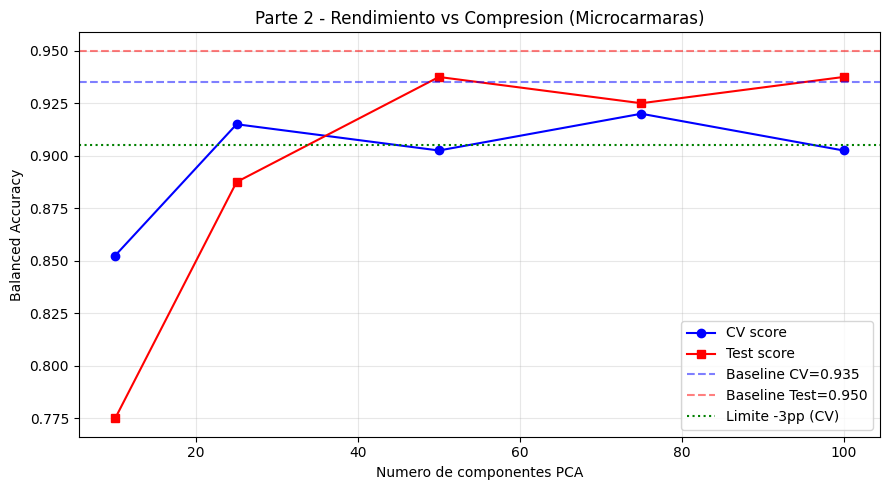

In [3]:
# == PCA sin argumentos para explorar varianza ====================
n_features_orig = X_train.shape[1]   # 4096

pca_full = PCA()
pca_full.fit(X_train)

var_acum = pca_full.explained_variance_ratio_.cumsum()
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum)
plt.axhline(y=0.99, color='red',    linestyle='--', label='99%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada - PCA Olivetti")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# == Rango de compresion 0.2% - 2.5% (al menos 5 valores) ========
# Compresion = n_pcs / 4096 * 100
# 0.2% -> 4096*0.002 aprox 8  |  2.5% -> 4096*0.025 aprox 102
n_pcs_range = [10, 25, 50, 75, 100]
print("Rango compresion Parte 2:")
for n in n_pcs_range:
    print(f"  n={n:3d} -> {n/n_features_orig*100:.3f}%")

# == Entrenar RF para cada numero de PCs ==========================
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_p2 = []

for n_pcs in n_pcs_range:
    pca_n = PCA(n_components=n_pcs)
    X_tr_pca = pca_n.fit_transform(X_train)
    X_te_pca = pca_n.transform(X_test)

    cv_score   = cross_val_score(rf_pca, X_tr_pca, y_train, cv=5,
                                 scoring='balanced_accuracy').mean()
    rf_pca.fit(X_tr_pca, y_train)
    test_score = balanced_accuracy_score(y_test, rf_pca.predict(X_te_pca))

    comp_pct = n_pcs / n_features_orig * 100
    results_p2.append({
        'n_componentes'        : n_pcs,
        'compresion_%'         : round(comp_pct, 3),
        'balanced_acc_CV'      : round(cv_score,   4),
        'balanced_acc_test'    : round(test_score, 4),
        'diff_CV_vs_baseline'  : round(cv_score   - baseline_cv,   4),
        'diff_test_vs_baseline': round(test_score - baseline_test, 4),
    })
    print(f"PCs={n_pcs:3d} ({comp_pct:.3f}%) | CV={cv_score:.4f} | Test={test_score:.4f}")

df_p2 = pd.DataFrame(results_p2)
print("\nResumen Parte 2:")
print(df_p2.to_string(index=False))

# == Escoger mayor compresion con perdida < 3pp ===================
umbral = 0.03
cands = df_p2[
    (df_p2['diff_CV_vs_baseline']   >= -umbral) &
    (df_p2['diff_test_vs_baseline'] >= -umbral)
]
if cands.empty:
    umbral = 0.05
    cands = df_p2[
        (df_p2['diff_CV_vs_baseline']   >= -umbral) &
        (df_p2['diff_test_vs_baseline'] >= -umbral)
    ]
    print("\nNo hay candidatos con perdida <3pp. Umbral ampliado a 5pp.")

best_cam = cands.loc[cands['compresion_%'].idxmin()]
print(f"\nMejor opcion microcarmaras (mayor compresion, perdida <{int(umbral*100)}pp):")
print(f"  n_componentes = {int(best_cam['n_componentes'])}")
print(f"  Compresion    = {best_cam['compresion_%']:.3f}%")
print(f"  CV score      = {best_cam['balanced_acc_CV']:.4f}")
print(f"  Test score    = {best_cam['balanced_acc_test']:.4f}")

# == Grafico comparativo ==========================================
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_p2['n_componentes'], df_p2['balanced_acc_CV'],   'bo-', label='CV score')
ax.plot(df_p2['n_componentes'], df_p2['balanced_acc_test'], 'rs-', label='Test score')
ax.axhline(y=baseline_cv,        color='blue', linestyle='--', alpha=0.5,
           label=f'Baseline CV={baseline_cv:.3f}')
ax.axhline(y=baseline_test,      color='red',  linestyle='--', alpha=0.5,
           label=f'Baseline Test={baseline_test:.3f}')
ax.axhline(y=baseline_cv - 0.03, color='green', linestyle=':', label='Limite -3pp (CV)')
ax.set_xlabel("Numero de componentes PCA")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Parte 2 - Rendimiento vs Compresion (Microcarmaras)")
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

Rango compresion Parte 3:
  n= 5 -> 0.122%
  n=10 -> 0.244%
  n=20 -> 0.488%
  n=30 -> 0.732%
  n=41 -> 1.001%


PCs= 5 (0.122%) | Test=0.6250 | Dbase=-0.3250


PCs=10 (0.244%) | Test=0.8250 | Dbase=-0.1250


PCs=20 (0.488%) | Test=0.8875 | Dbase=-0.0625


PCs=30 (0.732%) | Test=0.9250 | Dbase=-0.0250


PCs=41 (1.001%) | Test=0.9500 | Dbase=0.0000

Resumen Parte 3:
 n_componentes  compresion_%  balanced_acc_test  diff_vs_baseline
             5         0.122             0.6250           -0.3250
            10         0.244             0.8250           -0.1250
            20         0.488             0.8875           -0.0625
            30         0.732             0.9250           -0.0250
            41         1.001             0.9500            0.0000


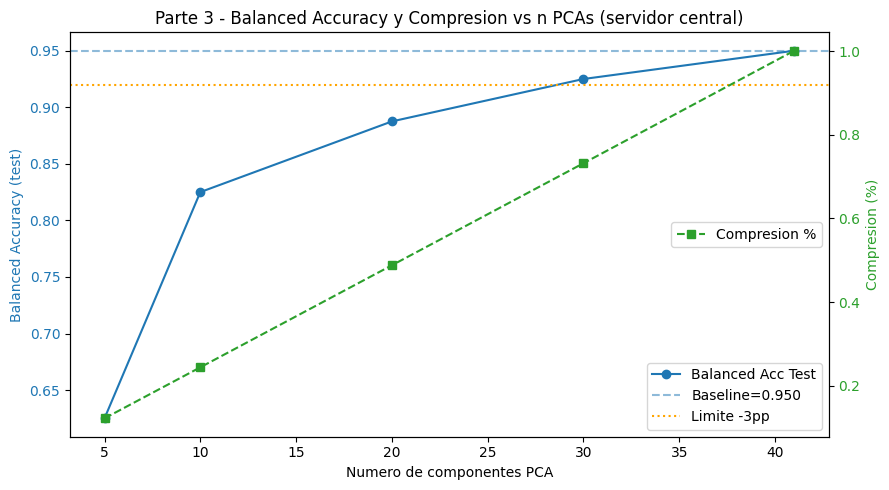


Recomendacion (perdida < 3pp vs baseline):
  -> 30 componentes (0.732% del tamano original)
  -> Balanced Accuracy test = 0.9250


In [4]:
# == Rango de compresion 0.1% - 1% (5 valores) ===================
# 1/1000 de 4096 aprox 4 componentes  |  1/100 de 4096 aprox 41
n_pcs_range_3 = [5, 10, 20, 30, 41]
n_features_orig = X_train.shape[1]   # 4096

print("Rango compresion Parte 3:")
for n in n_pcs_range_3:
    print(f"  n={n:2d} -> {n/n_features_orig*100:.3f}%")

# == Comprimir -> descomprimir -> entrenar -> evaluar ==============
rf_inv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_p3 = []

for n_pcs in n_pcs_range_3:
    pca_n = PCA(n_components=n_pcs)

    X_tr_comp  = pca_n.fit_transform(X_train)
    X_tr_unzip = pca_n.inverse_transform(X_tr_comp)

    X_te_comp  = pca_n.transform(X_test)
    X_te_unzip = pca_n.inverse_transform(X_te_comp)

    rf_inv.fit(X_tr_unzip, y_train)
    test_score = balanced_accuracy_score(y_test, rf_inv.predict(X_te_unzip))

    comp_pct = n_pcs / n_features_orig * 100
    results_p3.append({
        'n_componentes'    : n_pcs,
        'compresion_%'     : round(comp_pct, 3),
        'balanced_acc_test': round(test_score, 4),
        'diff_vs_baseline' : round(test_score - baseline_test, 4),
    })
    print(f"PCs={n_pcs:2d} ({comp_pct:.3f}%) | Test={test_score:.4f} | Dbase={test_score - baseline_test:.4f}")

df_p3 = pd.DataFrame(results_p3)
print("\nResumen Parte 3:")
print(df_p3.to_string(index=False))

# == Visualizacion ================================================
fig, ax1 = plt.subplots(figsize=(9, 5))
color_acc  = 'tab:blue'
color_comp = 'tab:green'

ax1.plot(df_p3['n_componentes'], df_p3['balanced_acc_test'], 'o-',
         color=color_acc, label='Balanced Acc Test')
ax1.axhline(y=baseline_test,        color=color_acc, linestyle='--', alpha=0.5,
            label=f'Baseline={baseline_test:.3f}')
ax1.axhline(y=baseline_test - 0.03, color='orange',  linestyle=':',  label='Limite -3pp')
ax1.set_xlabel("Numero de componentes PCA")
ax1.set_ylabel("Balanced Accuracy (test)", color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.legend(loc='lower right')

ax2 = ax1.twinx()
ax2.plot(df_p3['n_componentes'], df_p3['compresion_%'], 's--',
         color=color_comp, label='Compresion %')
ax2.set_ylabel("Compresion (%)", color=color_comp)
ax2.tick_params(axis='y', labelcolor=color_comp)
ax2.legend(loc='center right')

plt.title("Parte 3 - Balanced Accuracy y Compresion vs n PCAs (servidor central)")
plt.tight_layout(); plt.show()

# == Recomendacion ================================================
cands3 = df_p3[df_p3['diff_vs_baseline'] >= -0.03]
if not cands3.empty:
    best3 = cands3.loc[cands3['compresion_%'].idxmin()]
    print("\nRecomendacion (perdida < 3pp vs baseline):")
else:
    best3 = df_p3.loc[df_p3['diff_vs_baseline'].idxmax()]
    print("\nNinguno alcanza <3pp de perdida. Mejor opcion disponible:")

print(f"  -> {int(best3['n_componentes'])} componentes "
      f"({best3['compresion_%']:.3f}% del tamano original)")
print(f"  -> Balanced Accuracy test = {best3['balanced_acc_test']:.4f}")


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

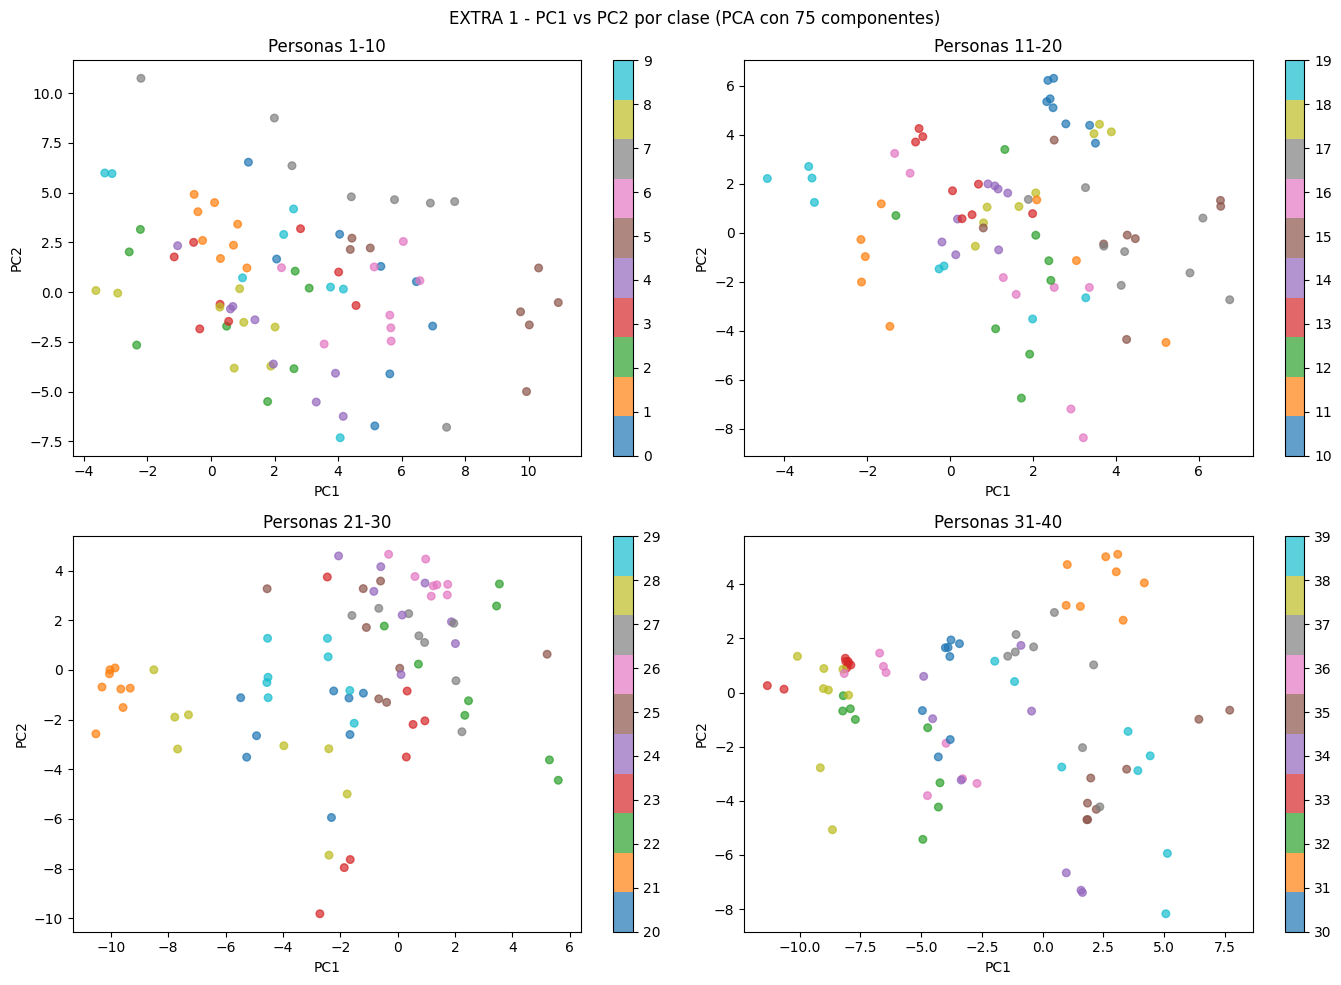

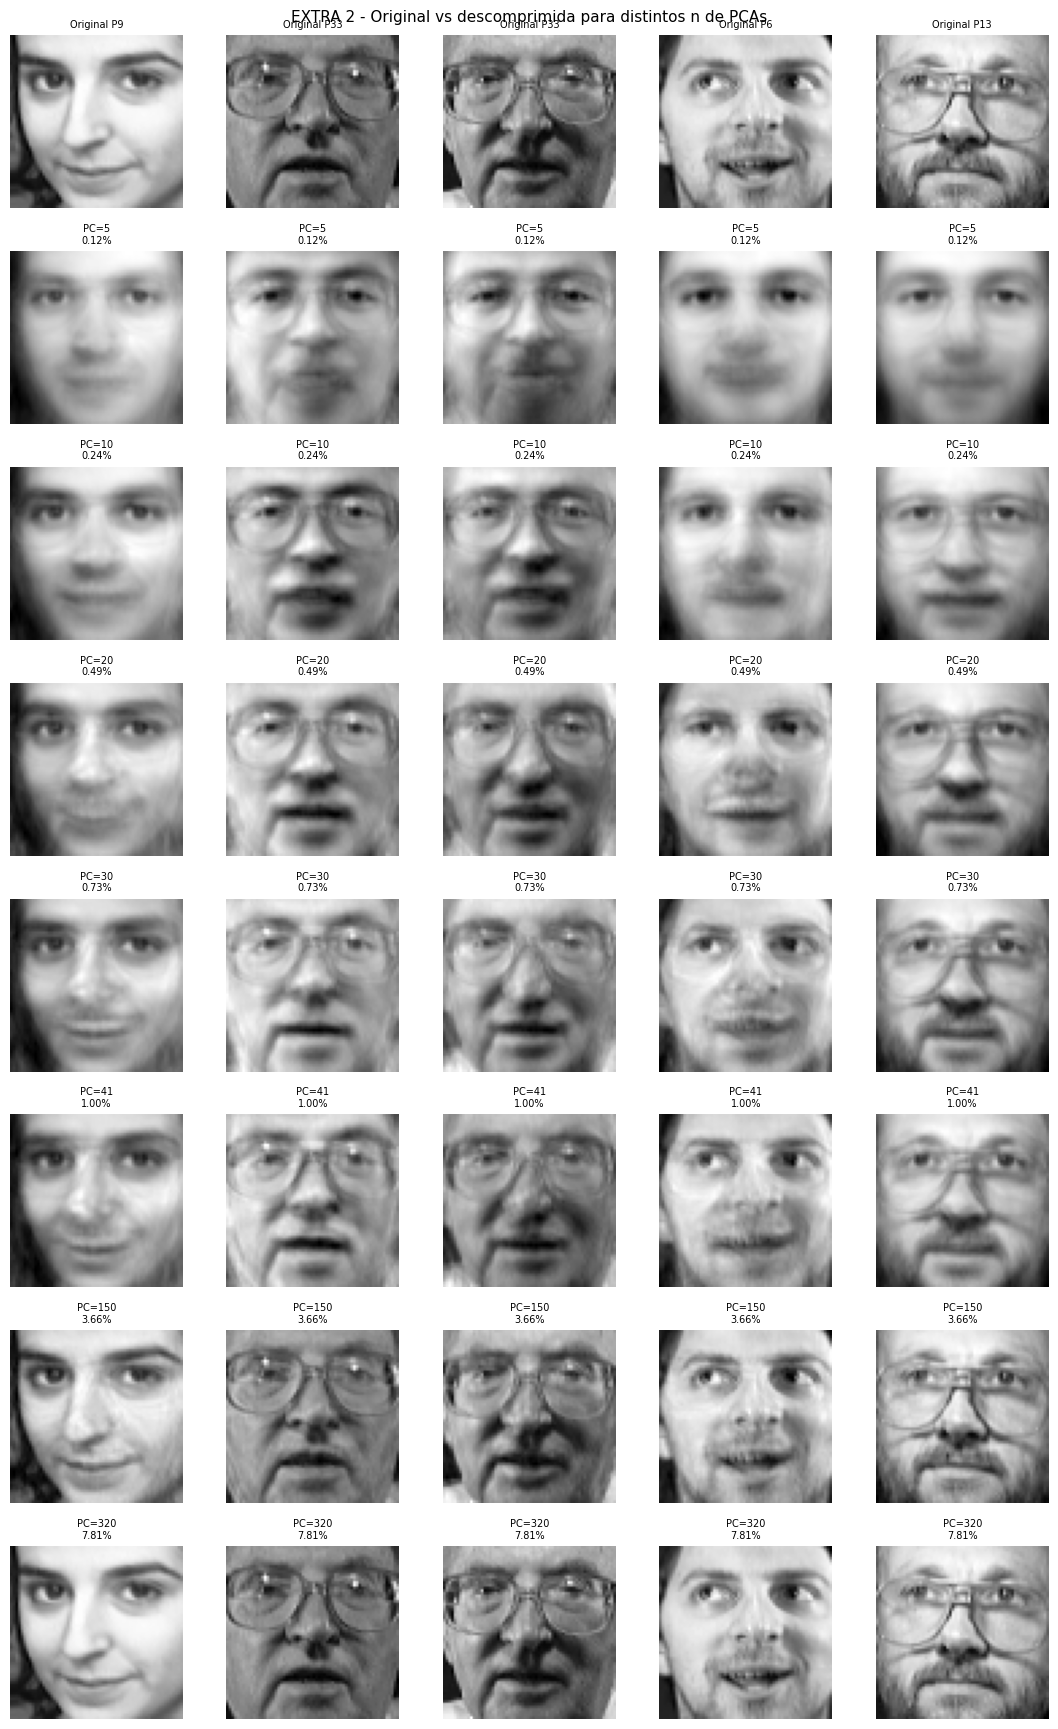

In [5]:
# == EXTRA 1: scatter PC1 vs PC2 (Parte 2) =======================
# Usa el mejor n_componentes de Parte 2 guardado en best_cam
best_n = max(int(best_cam['n_componentes']), 2)
pca_extra = PCA(n_components=best_n)
X_tr_extra = pca_extra.fit_transform(X_train)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
grupos = [(0, 10), (10, 20), (20, 30), (30, 40)]
for ax, (start, end) in zip(axes.flat, grupos):
    mask = (y_train >= start) & (y_train < end)
    sc = ax.scatter(X_tr_extra[mask, 0], X_tr_extra[mask, 1],
                    c=y_train[mask], cmap='tab10', s=30, alpha=0.7)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"Personas {start+1}-{end}")
    plt.colorbar(sc, ax=ax)
plt.suptitle(f"EXTRA 1 - PC1 vs PC2 por clase (PCA con {best_n} componentes)", fontsize=12)
plt.tight_layout(); plt.show()

# == EXTRA 2: caras originales vs descomprimidas (Parte 3) ========
def plot_original_vs_reconstructed(X_orig, y_orig, lista_n_pcs, n_faces=5):
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X_orig), size=n_faces, replace=False)

    n_rows = len(lista_n_pcs) + 1
    n_cols = n_faces
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.2))

    for j, i in enumerate(idx):
        axes[0, j].imshow(X_orig[i].reshape(64, 64), cmap='gray')
        axes[0, j].set_title(f"Original P{y_orig[i]}", fontsize=7)
        axes[0, j].axis('off')

    for row, n_pcs in enumerate(lista_n_pcs, start=1):
        pca_tmp = PCA(n_components=n_pcs)
        X_comp = pca_tmp.fit_transform(X_orig)
        X_rec  = pca_tmp.inverse_transform(X_comp)
        for j, i in enumerate(idx):
            axes[row, j].imshow(X_rec[i].reshape(64, 64), cmap='gray')
            axes[row, j].set_title(f"PC={n_pcs}\n{n_pcs/4096*100:.2f}%", fontsize=7)
            axes[row, j].axis('off')

    plt.suptitle("EXTRA 2 - Original vs descomprimida para distintos n de PCAs", fontsize=11)
    plt.tight_layout(); plt.show()

# Valores de Parte 3 + 150 y 320 como referencia de alta calidad
plot_original_vs_reconstructed(X_train, y_train, n_pcs_range_3 + [150, 320], n_faces=5)
